In [9]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

In [10]:
#dataset
data = {
    "NIM": ["TI001","TI002","TI003","TI004","TI005","TI006","TI007","TI008","TI009","TI010"],
    "Hasil_Sebenarnya": ["Lulus","Lulus","Lulus","Lulus","Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"],
    "Hasil_Prediksi":   ["Lulus","Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]
}

df = pd.DataFrame(data)
print("Dataset Awal:")
print(df)

Dataset Awal:
     NIM Hasil_Sebenarnya Hasil_Prediksi
0  TI001            Lulus          Lulus
1  TI002            Lulus          Lulus
2  TI003            Lulus    Tidak Lulus
3  TI004            Lulus    Tidak Lulus
4  TI005            Lulus    Tidak Lulus
5  TI006      Tidak Lulus          Lulus
6  TI007      Tidak Lulus    Tidak Lulus
7  TI008      Tidak Lulus    Tidak Lulus
8  TI009      Tidak Lulus    Tidak Lulus
9  TI010      Tidak Lulus    Tidak Lulus


In [11]:
#missing
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
NIM                 0
Hasil_Sebenarnya    0
Hasil_Prediksi      0
dtype: int64


In [12]:
encode = {"Lulus": 1, "Tidak Lulus": 0}

df["Actual"] = df["Hasil_Sebenarnya"].map(encode)
df["Predicted"] = df["Hasil_Prediksi"].map(encode)

print("\nDataset Setelah Encoding:")
print(df)


Dataset Setelah Encoding:
     NIM Hasil_Sebenarnya Hasil_Prediksi  Actual  Predicted
0  TI001            Lulus          Lulus       1          1
1  TI002            Lulus          Lulus       1          1
2  TI003            Lulus    Tidak Lulus       1          0
3  TI004            Lulus    Tidak Lulus       1          0
4  TI005            Lulus    Tidak Lulus       1          0
5  TI006      Tidak Lulus          Lulus       0          1
6  TI007      Tidak Lulus    Tidak Lulus       0          0
7  TI008      Tidak Lulus    Tidak Lulus       0          0
8  TI009      Tidak Lulus    Tidak Lulus       0          0
9  TI010      Tidak Lulus    Tidak Lulus       0          0



Confusion Matrix:
[[4 1]
 [3 2]]


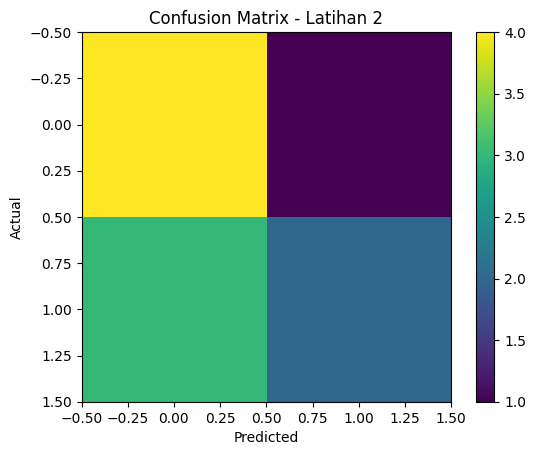

In [13]:
#confusion matrix
y_true = df["Actual"]
y_pred = df["Predicted"]

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualisasi matrix
plt.imshow(cm)
plt.title("Confusion Matrix - Latihan 2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [14]:
#hitung accuracy

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)

print("\n=== HASIL PERHITUNGAN ===")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


=== HASIL PERHITUNGAN ===
Accuracy : 0.6
Precision: 0.6666666666666666
Recall   : 0.4


In [15]:
df["Index"] = df.index

X = df[["Index"]]
y = df["Actual"]

nb = GaussianNB()
nb.fit(X, y)

pred_nb = nb.predict(X)

print("\n=== Prediksi Naive Bayes (Dummy Fitur) ===")
print(pred_nb)


=== Prediksi Naive Bayes (Dummy Fitur) ===
[1 1 1 1 1 0 0 0 0 0]
